# Edge Detection in Image Processing
### Simple Gradient, Sobel, Laplacian, and Canny

This notebook introduces basic **edge detection techniques** used in image processing.

Students will learn:
- Simple gradient edge detection
- Sobel operator
- Laplacian operator
- Canny edge detector

These methods are fundamental in **computer vision**, **medical imaging**, and **AI-based image analysis**.

## 1. Import Required Libraries
We use:
- `OpenCV` for image processing
- `NumPy` for numerical operations
- `Matplotlib` for visualization

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. Load an Image

You can either:
- Upload your own image in Colab
- Or use the sample image below.

(np.float64(-0.5), np.float64(1439.5), np.float64(1109.5), np.float64(-0.5))

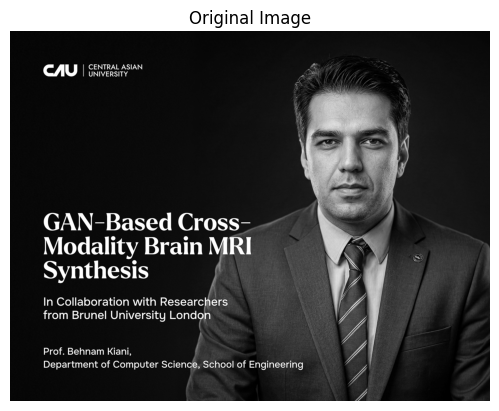

In [6]:
# If running in Google Colab, uncomment below to upload an image
# from google.colab import files
# uploaded = files.upload()

# Load example image from internet
import urllib.request

url = 'https://static.tildacdn.com/tild6530-6465-4134-a165-373062643564/Centralasianuz_news_.jpg'
urllib.request.urlretrieve(url, 'image.png')

image = cv2.imread('image.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

## 3. Simple Gradient Edge Detection

Edges correspond to **rapid intensity changes**.

A simple way to detect edges is by computing gradients in the **x** and **y** directions.

(np.float64(-0.5), np.float64(1439.5), np.float64(1109.5), np.float64(-0.5))

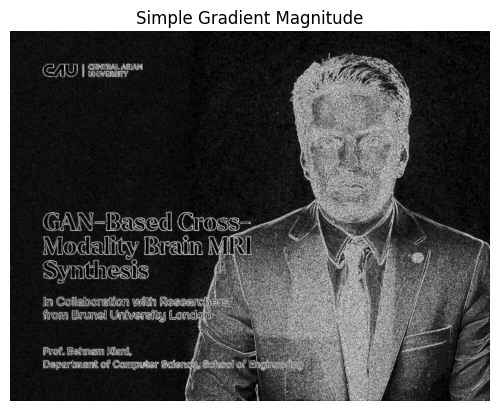

In [7]:
gx = np.zeros_like(image)
gy = np.zeros_like(image)

gx[:, :-1] = np.diff(image, axis=1)
gy[:-1, :] = np.diff(image, axis=0)

gradient_magnitude = np.sqrt(gx**2 + gy**2)

plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Simple Gradient Magnitude')
plt.axis('off')

## 4. Sobel Edge Detector

The **Sobel operator** computes gradients using convolution kernels.

It detects:
- Horizontal edges
- Vertical edges

# Sobel Edge Detection – Complete Guide

The **Sobel operator** is a first-order derivative method used to detect **edges in specific directions** (horizontal or vertical).  
It calculates the gradient of image intensity using **convolution with Sobel kernels**.

Unlike the Laplacian, which detects edges in all directions, the Sobel operator can detect:

- **Horizontal edges** (changes along the y-axis)  
- **Vertical edges** (changes along the x-axis)

---

## 1. OpenCV Function

In OpenCV, Sobel is implemented as:

```python
sobel = cv2.Sobel(src, ddepth, dx, dy[, ksize[, scale[, delta[, borderType]]]])

## Sobel Function Arguments

| Argument      | Description |
|---------------|-------------|
| `src`         | Input image (grayscale or color). |
| `ddepth`      | Desired depth of the output image (e.g., `cv2.CV_64F` to avoid overflow). |
| `dx`          | Order of the derivative in the x direction. Use 1 for horizontal gradients. |
| `dy`          | Order of the derivative in the y direction. Use 1 for vertical gradients. |
| `ksize`       | (Optional) Size of the extended Sobel kernel. Must be **odd** (1, 3, 5, 7). Default = 3. |
| `scale`       | (Optional) Optional scale factor applied to the computed derivative values. Default = 1. |
| `delta`       | (Optional) Optional value added to the results before storing in output. Default = 0. |
| `borderType`  | (Optional) Pixel extrapolation method at borders. Default = `cv2.BORDER_DEFAULT`. |

(np.float64(-0.5), np.float64(1439.5), np.float64(1109.5), np.float64(-0.5))

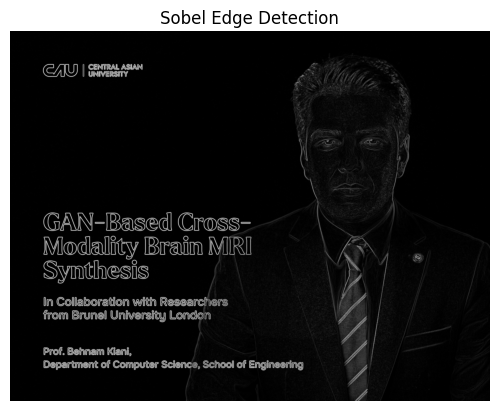

In [8]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')

## 5. Laplacian Edge Detection

The **Laplacian operator** detects edges by computing the **second derivative** of the image.

It highlights regions where intensity changes rapidly.

# Laplacian Edge Detection – Complete Guide

The **Laplacian operator** is a second-order derivative method used to detect edges in an image.  
It highlights areas where the **intensity changes rapidly**, such as edges, corners, or boundaries.

Unlike Sobel or simple gradients, which detect edges in **specific directions (x or y)**, the Laplacian is **isotropic**, meaning it detects edges in **all directions**.

---

## 1. OpenCV Function

In OpenCV, the Laplacian is implemented as:

```python
laplacian = cv2.Laplacian(src, ddepth[, dst[, ksize[, scale[, delta[, borderType]]]]])

## Laplacian Function Arguments

| Argument      | Description |
|---------------|-------------|
| `src`         | Input image (grayscale or color). |
| `ddepth`      | Desired depth of the output image (e.g., `cv2.CV_64F` to avoid overflow). |
| `dst`         | (Optional) Output image of the same size as input. |
| `ksize`       | (Optional) Kernel size for the Laplacian filter. Must be **odd** (1, 3, 5, 7). Default = 1. |
| `scale`       | (Optional) Optional scale factor applied to the computed Laplacian values. Default = 1. |
| `delta`       | (Optional) Optional value added to the result before storing in `dst`. Default = 0. |
| `borderType`  | (Optional) Pixel extrapolation method at borders. Default = `cv2.BORDER_DEFAULT`. |

(np.float64(-0.5), np.float64(1439.5), np.float64(1109.5), np.float64(-0.5))

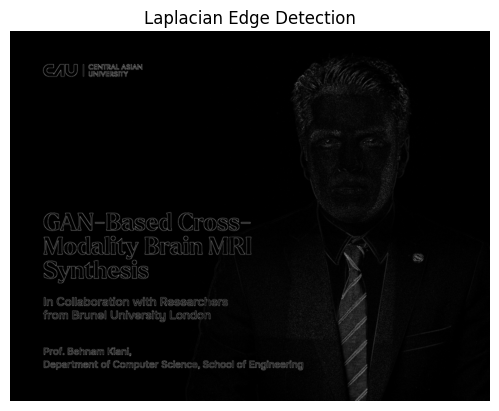

In [9]:
laplacian = cv2.Laplacian(image, cv2.CV_64F)

plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian Edge Detection')
plt.axis('off')

## 6. Canny Edge Detector

The **Canny algorithm** is one of the most powerful edge detection techniques.

Steps:
1. Noise reduction (Gaussian blur)
2. Gradient calculation
3. Non‑maximum suppression
4. Double threshold
5. Edge tracking by hysteresis

# Canny Edge Detection – Complete Guide

The **Canny Edge Detector** is one of the most widely used edge detection algorithms in **image processing** and **computer vision**. It was developed by **John F. Canny (1986)** with the goal of detecting edges **accurately**, **robustly**, and **with minimal noise sensitivity**.

Unlike simple gradient-based operators (like Sobel or Laplacian), Canny is a **multi-stage algorithm** designed to produce **thin, continuous, and well-localized edges**.

---

## 1. OpenCV Function

In OpenCV, the Canny edge detector is implemented as:

```python
edges = cv2.Canny(image, threshold1, threshold2[, edges[, apertureSize[, L2gradient]]])

## Canny Function Arguments

| Argument       | Description |
|----------------|-------------|
| `image`        | Input image (must be **single-channel grayscale**). |
| `threshold1`   | Lower threshold for the hysteresis procedure. Pixels with gradient **below this are rejected**. |
| `threshold2`   | Upper threshold for hysteresis. Pixels **above this are considered strong edges**. |
| `edges`        | (Optional) Output image; same size and type as input. |
| `apertureSize` | (Optional) Size of the Sobel kernel used for gradient calculation. Typical values: **3, 5, 7**. Default = 3. |
| `L2gradient`   | (Optional) Boolean flag. If `True`, gradient magnitude is computed using **√(Gx² + Gy²)** for higher accuracy. Default = `False` (approximated with |Gx| + |Gy|). |

(np.float64(-0.5), np.float64(1439.5), np.float64(1109.5), np.float64(-0.5))

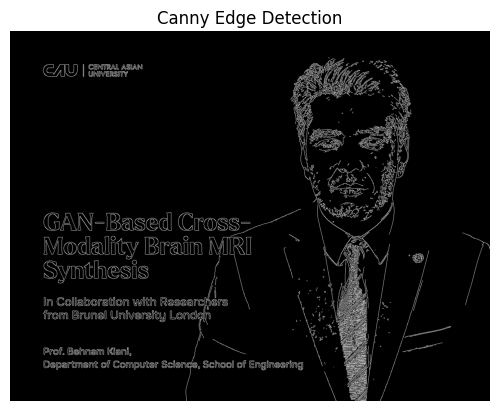

In [10]:
canny = cv2.Canny(image, 100, 200)

plt.imshow(canny, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

## 7. Comparison of All Methods

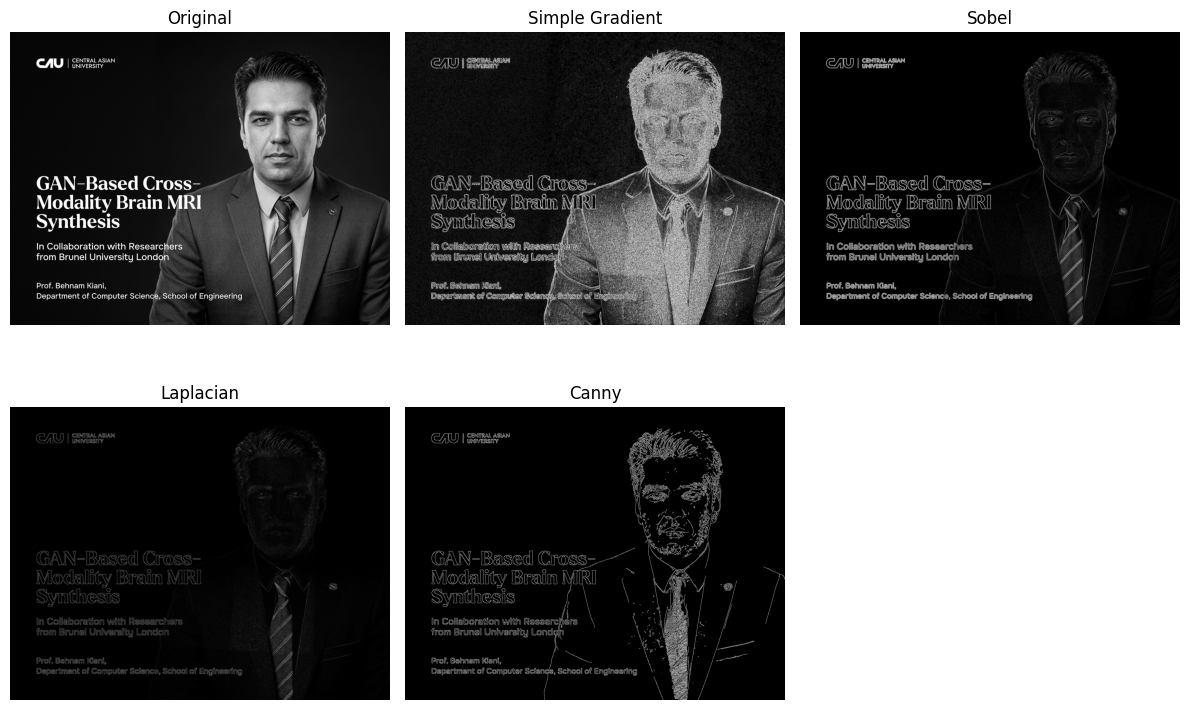

In [11]:
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Simple Gradient')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(np.abs(laplacian), cmap='gray')
plt.title('Laplacian')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(canny, cmap='gray')
plt.title('Canny')
plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Exercises for Students

1. Change the **Canny thresholds** and observe the effect.
2. Apply **Gaussian blur** before Sobel and Laplacian.
3. Test different images (medical images, natural images).
4. Compare which method detects edges **more clearly**.

Discussion questions:
- Which method is more sensitive to noise?
- Why is Canny considered a multi‑stage detector?